# 01 — Data Exploration

Explore the CZ CELLxGENE Census at scale. No data is downloaded — metadata is streamed via TileDB-SOMA.

**Census LTS release:** 2025-11-08  
**Scale:** ~162M human cells, 1,845 datasets, 898 cell types, 417 tissues

In [1]:
import sys
sys.path.insert(0, '..')

import cellxgene_census
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CENSUS_VERSION = '2025-11-08'

## Census-wide metadata

### obs schema — one row per cell

Each cell in the Census is described by the following metadata columns. These are what you filter and group by throughout the pipeline.

| Column | Type | Description | Gotchas |
|--------|------|-------------|---------|
| `soma_joinid` | `int64` | Unique row ID within this SOMA object. Used to fetch the matching expression row. | Not stable across Census releases — don't store and reuse across versions. |
| `dataset_id` | `string` | Source dataset the cell came from (maps to a published paper / GEO submission). | |
| `assay` | `string` | Sequencing chemistry, e.g. `10x 3' v3`, `Smart-seq2`. Major source of batch effects. | Contains literal single quotes — string filters must use double-quote delimiters. |
| `assay_ontology_term_id` | `string` | EFO ontology ID for the assay, e.g. `EFO:0009899`. | |
| `cell_type` | `string` | Human-readable cell type label, e.g. `CD4-positive, alpha-beta T cell`. | Granularity varies across datasets; some use broad labels, others fine-grained subtypes. |
| `cell_type_ontology_term_id` | `string` | CL ontology ID, e.g. `CL:0000624`. More stable than the label for programmatic use. | |
| `tissue` | `string` | Precise tissue of origin (e.g. `right lobe of liver`). | |
| `tissue_general` | `string` | Coarser tissue grouping (e.g. `liver`). Use this for cross-dataset grouping. | |
| `tissue_ontology_term_id` | `string` | UBERON or CL ontology ID. | |
| `disease` | `string` | Disease state, e.g. `normal`, `COVID-19`. | **Multi-value**: can contain `disease_A \|\| disease_B`. Exact-match filters silently miss these rows — use regex or `str.contains`. |
| `disease_ontology_term_id` | `string` | MONDO ontology ID. Same multi-value issue applies. | |
| `donor_id` | `string` | Per-dataset donor identifier. **Not globally unique** — the same string can appear in different datasets from different people. | Always disambiguate with `dataset_id` when doing cross-dataset donor analysis. |
| `sex` | `string` | `male`, `female`, or `unknown`. | |
| `development_stage` | `string` | Life stage label, e.g. `adult`, `50-year-old human stage`. | Format varies by organism and dataset. |
| `self_reported_ethnicity` | `string` | Self-reported ethnicity of the donor. | Only meaningful for human; `na` for other organisms. |
| `suspension_type` | `string` | `cell` or `nucleus` — distinguishes single-cell from single-nucleus RNA-seq. | Mixing the two adds a systematic batch effect. |
| `is_primary_data` | `bool` | `True` if this cell is the canonical version in the Census. Cells from multi-tissue studies appear in multiple datasets; only one copy is primary. | **Always filter to `is_primary_data == True`** to avoid double-counting. |
| `observation_joinid` | `string` | Stable per-cell ID within its source dataset. | |

---

### var schema — one row per gene

The gene axis is shared across all cells. Census standardizes to a fixed gene universe (Ensembl release pinned per Census version).

| Column | Type | Description |
|--------|------|-------------|
| `soma_joinid` | `int64` | Unique gene row ID. |
| `feature_id` | `string` | Ensembl gene ID, e.g. `ENSG00000139618`. Stable identifier — use this for cross-dataset joins. |
| `feature_name` | `string` | Gene symbol, e.g. `BRCA2`. Human-readable but not always unique. |
| `feature_length` | `int64` | Gene body length in base pairs. Used for RPKM/TPM normalization (not needed for 10x data). |
| `feature_type` | `string` | `gene` for protein-coding and lncRNA; `spike-in` for ERCC controls. Filter to `gene` before analysis. |

---

### Key filtering fields for this project

| What you want | Filter to use | Why |
|---------------|---------------|-----|
| Primary cells only | `is_primary_data == True` | Cells from multi-tissue studies are deposited in multiple datasets. Without this, the same cell appears more than once, inflating counts and leaking duplicates across train/test splits. |
| Specific tissues | `tissue_general in ['blood', 'lung']` | Restricts the cell-type vocabulary to a manageable set and keeps batch effects within a known domain. Mixing unrelated tissues (e.g. brain + blood) introduces cell types that never co-occur in real samples, making cross-donor evaluation artifically hard. |
| Standard 10x chemistry | `assay == "10x 3' v3"` (use double quotes) | Different assays capture different gene sets and have different noise profiles. A classifier trained on 10x data applied to Smart-seq2 data will fail for technical reasons, not biological ones. Fixing a single assay isolates the biological signal we care about. |
| Healthy donors only | `disease` contains `"normal"` via regex | Disease alters cell-type composition and gene expression in ways that are interesting scientifically but confounding here — a COVID-19 sample has an expanded monocyte population that a healthy-trained classifier will mislabel. Restricting to normal lets the model learn baseline cell identity. |
| Adult cells only | `development_stage` contains `"adult"` via regex | Gene expression programs differ substantially between fetal, infant, and adult tissue. A fetal liver contains hematopoietic stem cells that are absent in adult blood; including them adds spurious cell types and inflates apparent cross-donor difficulty. |

### Summary

In [8]:
# Stream top-level summary without loading any expression data
with cellxgene_census.open_soma(census_version=CENSUS_VERSION) as census:
    summary = cellxgene_census.get_census_version_description(CENSUS_VERSION)

summary

{'release_date': None,
 'release_build': '2025-11-08',
 'soma': {'uri': 's3://cellxgene-census-public-us-west-2/cell-census/2025-11-08/soma/',
  'relative_uri': '/cell-census/2025-11-08/soma/',
  's3_region': 'us-west-2'},
 'h5ads': {'uri': 's3://cellxgene-census-public-us-west-2/cell-census/2025-11-08/h5ads/',
  'relative_uri': '/cell-census/2025-11-08/h5ads/',
  's3_region': 'us-west-2'},
 'flags': {'lts': True}}

In [5]:
# Fetch obs metadata for a manageable slice: blood + lung
with cellxgene_census.open_soma(census_version=CENSUS_VERSION) as census:
    obs = census['census_data']['homo_sapiens'].obs.read(
        value_filter="tissue_general in ['blood', 'lung'] and assay == \"10x 3' v3\"",
        column_names=['soma_joinid', 'tissue_general', 'cell_type', 'donor_id',
                      'disease', 'assay', 'sex', 'is_primary_data']
    ).concat().to_pandas()

obs = obs[obs['is_primary_data']].copy()
print(f"{len(obs):,} cells from blood + lung (primary data only)")
obs.head()

17,973,263 cells from blood + lung (primary data only)


,soma_joinid,tissue_general,cell_type,donor_id,disease,assay,sex,is_primary_data
6841,182329,blood,mature NK T cell,COV027,COVID-19,10x 3' v3,female,True
6842,182330,blood,mature NK T cell,COV027,COVID-19,10x 3' v3,female,True
6843,182331,blood,mature NK T cell,COV027,COVID-19,10x 3' v3,female,True
6844,182332,blood,mature NK T cell,COV027,COVID-19,10x 3' v3,female,True
6845,182333,blood,mature NK T cell,COV027,COVID-19,10x 3' v3,female,True


## Cell type distribution

### Cell type glossary — blood + lung slice

Cell types follow the [Cell Ontology (CL)](https://www.ebi.ac.uk/ols/ontologies/cl) hierarchy. Labels can be fine-grained (e.g. `CD4-positive, alpha-beta T cell`) or coarse (e.g. `T cell`) depending on how well the source study annotated their data — that inconsistency is itself a challenge for cross-dataset classifiers.

#### Blood

| Cell type label | Shorthand | What it is |
|-----------------|-----------|------------|
| `CD4-positive, alpha-beta T cell` | CD4+ T cell | Helper T cell. Coordinates adaptive immune responses by activating B cells and cytotoxic T cells via cytokine signaling. Most abundant T cell type in blood. |
| `CD8-positive, alpha-beta T cell` | CD8+ T cell | Cytotoxic T cell. Kills virus-infected or cancerous cells directly. Shares many marker genes with NK cells — a common confusion pair for classifiers. |
| `mature NK T cell` | NKT cell | Hybrid lymphocyte with properties of both NK and T cells. Recognizes lipid antigens via a semi-invariant T cell receptor. Distinct from NK cells despite the name. |
| `natural killer cell` | NK cell | Innate lymphocyte. Kills target cells without prior sensitization. Expresses cytotoxic genes (GNLY, PRF1, GZMB) shared with CD8+ T cells — the other common confusion pair. |
| `classical monocyte` | cMono | Large phagocyte that patrols blood and rapidly enters tissues during infection. High CD14, low CD16 expression. |
| `non-classical monocyte` | ncMono | Anti-inflammatory patrolling monocyte. Low CD14, high CD16. Differentiated from classical monocytes; occupies a continuum, making these two hard to separate at low sequencing depth. |
| `B cell` | B cell | Antibody-producing lymphocyte. Recognizes antigens via the B cell receptor. Precursor to plasma cells after activation. |
| `plasmablast` | — | Short-lived, rapidly dividing antibody-secreting cell, early in the B cell → plasma cell differentiation path. Expanded dramatically during acute infection. |
| `plasma cell` | — | Long-lived, terminally differentiated antibody factory. High immunoglobulin expression. Often confused with plasmablasts by classifiers when donor is acutely ill. |
| `conventional dendritic cell` | cDC | Antigen-presenting cell. Processes pathogens and presents peptides to T cells to initiate adaptive immunity. Low abundance — typically <1% of blood cells. |
| `plasmacytoid dendritic cell` | pDC | Specialized dendritic cell that produces massive amounts of type I interferon in response to viral infections. Distinct gene program from cDCs despite similar name. |
| `regulatory T cell` | Treg | Suppresses excessive immune responses. Expresses FOXP3. Rare in blood (~5–10% of CD4+ T cells); classifiers often collapse them into the broader CD4+ T cell category. |
| `erythrocyte` | RBC | Red blood cell. Carries oxygen. Lacks a nucleus and has almost no mRNA — should be filtered out in QC (very few detected genes). Presence in large numbers usually indicates poor sample preparation. |
| `platelet` | — | Cell fragment involved in clotting. Also nearly anucleate; appears in blood data as a low-count artifact. |

#### Lung

| Cell type label | Shorthand | What it is |
|-----------------|-----------|------------|
| `type II pneumocyte` | AT2 cell | Alveolar type 2 cell. Lines the air sacs (alveoli). Produces surfactant to prevent collapse. Progenitor of AT1 cells. Most abundant epithelial cell in the lung and a key COVID-19 target. |
| `type I pneumocyte` | AT1 cell | Alveolar type 1 cell. Extremely flat; forms the gas-exchange surface. Covers ~95% of alveolar area despite being fewer in number than AT2 cells. |
| `ciliated cell` | — | Lines the conducting airways. Cilia beat rhythmically to sweep mucus and debris toward the throat (mucociliary clearance). High expression of dynein motor genes. |
| `club cell` | Club / Clara | Secretory airway cell. Produces components of the airway surface liquid. Progenitor of ciliated cells. |
| `goblet cell` | — | Mucus-secreting airway cell. Expands dramatically in chronic airway disease (asthma, COPD). High MUC5AC expression. |
| `alveolar macrophage` | AM | Tissue-resident macrophage that patrols the alveolar space. First responder to inhaled pathogens. Different gene program from blood monocytes despite both being phagocytes — a cross-tissue confusion pair. |
| `interstitial macrophage` | IM | Macrophage resident in the lung interstitium (connective tissue between alveoli). Distinct from AMs but shares many markers. |
| `fibroblast` | — | Structural cell that produces extracellular matrix (collagen, elastin). Expands and remodels tissue after injury; central to fibrosis. |
| `capillary endothelial cell` | Cap EC | Lines the alveolar capillaries where gas exchange occurs. Highly specialized; distinct from endothelial cells in larger vessels. |
| `mast cell` | — | Tissue-resident immune cell packed with histamine granules. Key mediator of allergic responses. Very rare — typically <0.5% of lung cells. |

---

> **Classifier note:** The hardest cell types to distinguish are those that share a developmental lineage (plasmablast ↔ plasma cell, AT1 ↔ AT2), occupy a continuum (classical ↔ non-classical monocyte), or share cytotoxic gene programs (NK ↔ CD8+ T cell). These are the pairs to watch in the confusion matrix.

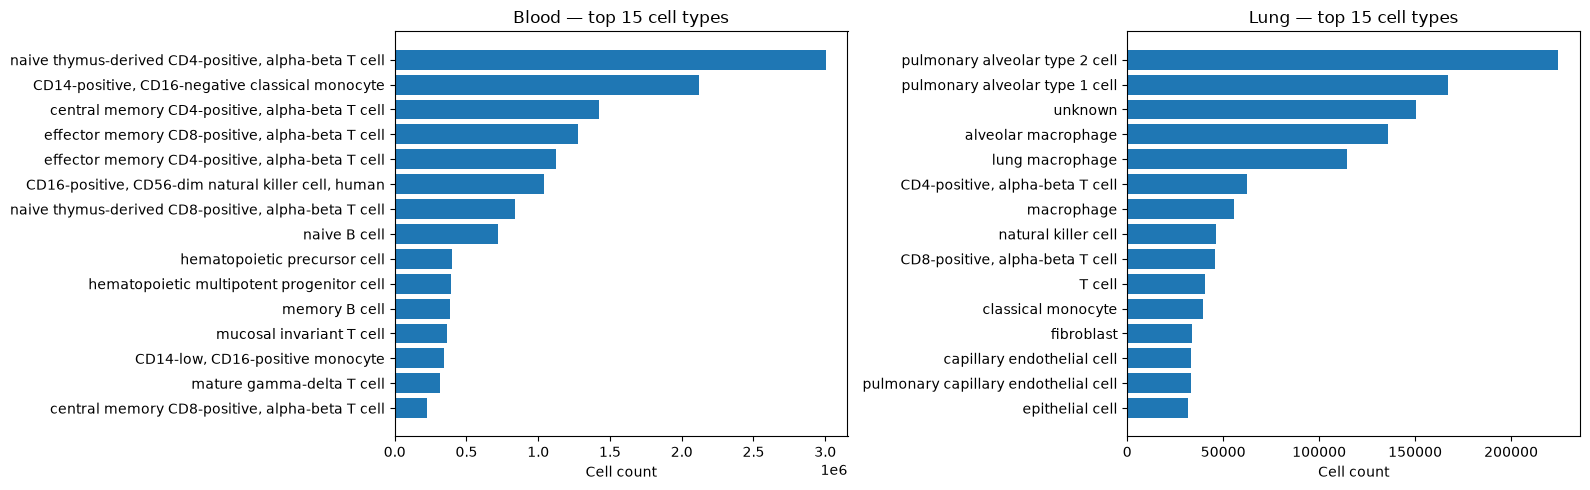

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, tissue in enumerate(['blood', 'lung']):
    top_types = (
        obs[obs['tissue_general'] == tissue]['cell_type']
        .value_counts().head(15)
    )
    axes[i].barh(top_types.index[::-1], top_types.values[::-1])
    axes[i].set_title(f'{tissue.capitalize()} — top 15 cell types')
    axes[i].set_xlabel('Cell count')

plt.tight_layout()
plt.show()

## Donor distribution — key for cross-donor evaluation

In [14]:
donor_counts = obs.groupby('tissue_general')['donor_id'].nunique()
cell_counts = obs.groupby('tissue_general').size()

pd.DataFrame({'donors': donor_counts, 'cells': cell_counts}).sort_values(ascending=False, by='donors')

/var/folders/b0/ywczwgn96m38mc0d7pnysfwc0000gn/T/ipykernel_13604/2007090765.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  donor_counts = obs.groupby('tissue_general')['donor_id'].nunique()
/var/folders/b0/ywczwgn96m38mc0d7pnysfwc0000gn/T/ipykernel_13604/2007090765.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = obs.groupby('tissue_general').size()


,donors,cells
tissue_general,,
blood,512,16129366
lung,226,1843897
abdomen,0,0
pancreas,0,0
prostate gland,0,0
...,...,...
intestine,0,0
kidney,0,0
lamina propria,0,0


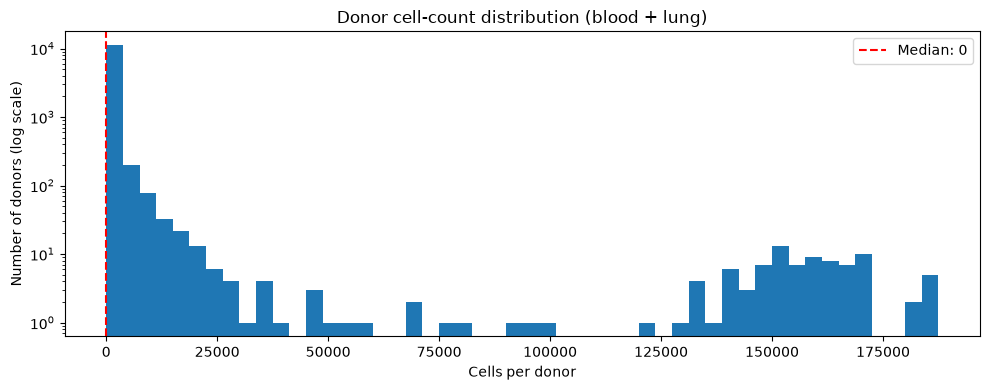

In [12]:
# Cells per donor — shows imbalance that must be handled in evaluation
cpd = obs['donor_id'].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cpd.values, bins=50, log=True)
ax.set_xlabel('Cells per donor')
ax.set_ylabel('Number of donors (log scale)')
ax.set_title('Donor cell-count distribution (blood + lung)')
ax.axvline(cpd.median(), color='red', linestyle='--', label=f'Median: {int(cpd.median())}')
ax.legend()
plt.tight_layout()
plt.show()

## Disease field — multi-value caveat

The `disease` field can contain multiple values delimited by ` || `. Exact-match filters silently miss these entries.

In [ ]:
multi_disease = obs[obs['disease'].str.contains(r'\|\|', na=False)]
print(f"Cells with multi-value disease field: {len(multi_disease):,}")
print("Example values:")
multi_disease['disease'].value_counts().head(10)

Cells with multi-value disease field: 0
Example values:


disease
Alzheimer disease                                            0
non-compaction cardiomyopathy                                0
kidney oncocytoma                                            0
leukoencephalopathy, diffuse hereditary, with spheroids 1    0
listeriosis                                                  0
liver cancer                                                 0
localized scleroderma                                        0
long COVID-19                                                0
luminal A breast carcinoma                                   0
luminal B breast carcinoma                                   0
Name: count, dtype: int64